Sample size: 1000
X: mean=0.0193, std=0.9787
Z: mean=5.1417, std=1.9939

Линейная зависимость Y = aX + (1-a)Z

a = 0
  Pearson:  r = -0.0404, p = 0.2018, reject H0: False
  Spearman: ρ = -0.0638, p = 0.0438, reject H0: True
  Kendall:  τ = -0.0438, p = 0.0380, reject H0: True

a = 0.25
  Pearson:  r = 0.1224, p = 0.0001, reject H0: True
  Spearman: ρ = 0.0909, p = 0.0040, reject H0: True
  Kendall:  τ = 0.0601, p = 0.0044, reject H0: True

a = 0.5
  Pearson:  r = 0.4110, p = 0.0000, reject H0: True
  Spearman: ρ = 0.3793, p = 0.0000, reject H0: True
  Kendall:  τ = 0.2580, p = 0.0000, reject H0: True

a = 0.75
  Pearson:  r = 0.8201, p = 0.0000, reject H0: True
  Spearman: ρ = 0.8098, p = 0.0000, reject H0: True
  Kendall:  τ = 0.6132, p = 0.0000, reject H0: True

a = 1
  Pearson:  r = 1.0000, p = 0.0000, reject H0: True
  Spearman: ρ = 1.0000, p = 0.0000, reject H0: True
  Kendall:  τ = 1.0000, p = 0.0000, reject H0: True

Кубическая зависимость Y = 0.05X³ + 4Z
  Pearson:  r = -0.0223

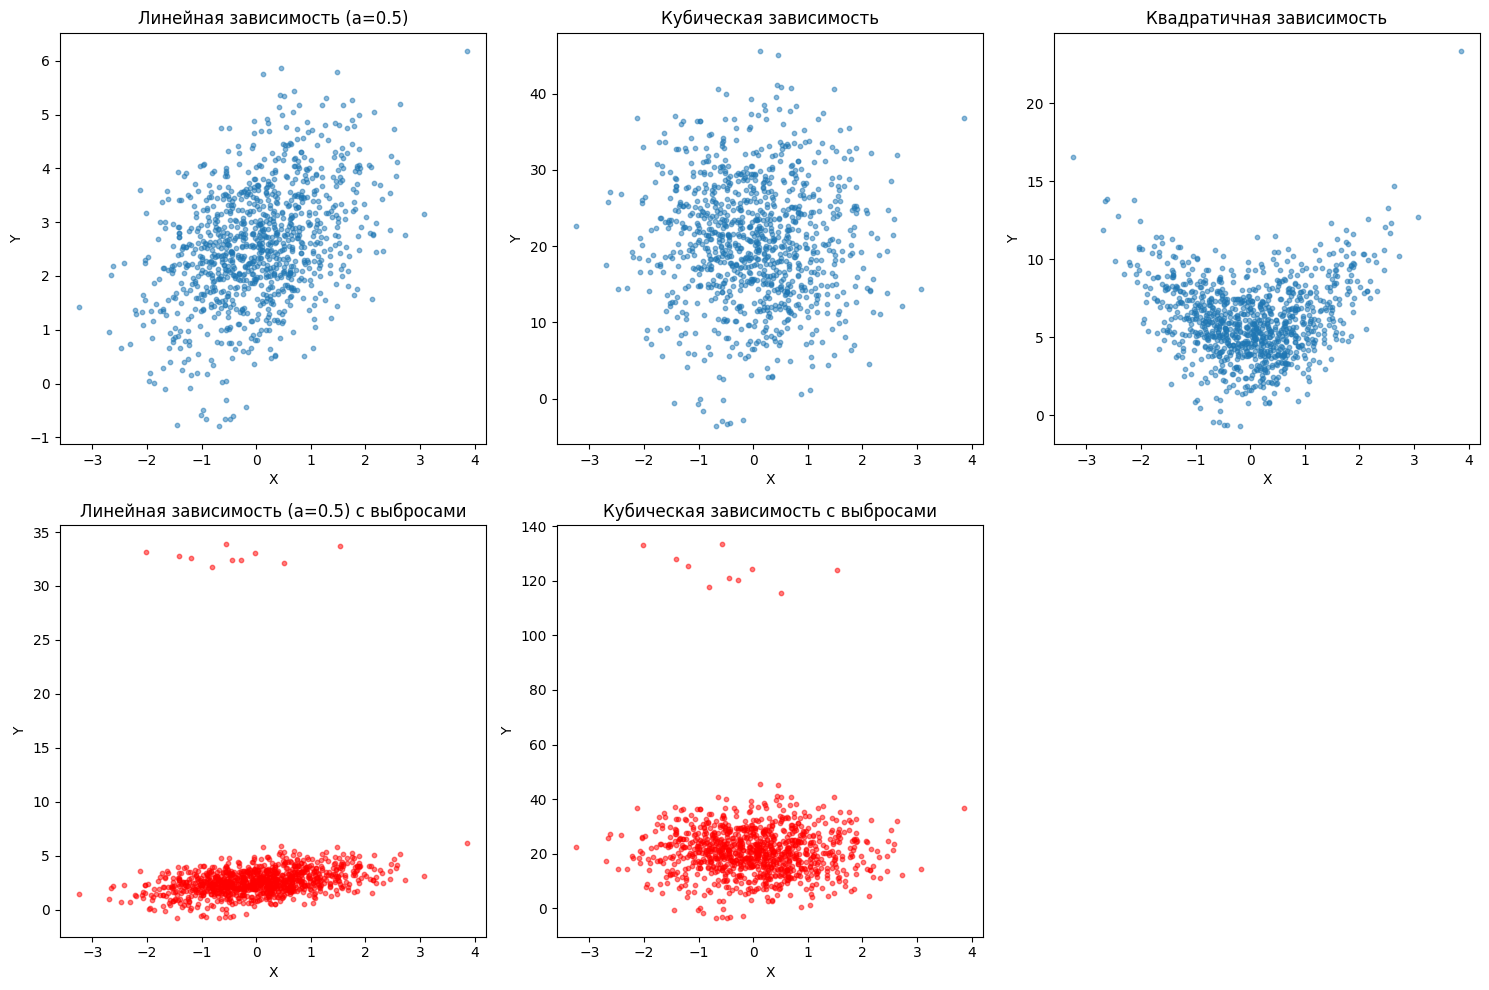

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)

# Генерация данных
n = 1000
X = np.random.normal(0, 1, n)
Z = np.random.normal(5, 2, n)

print(f"Sample size: {n}")
print(f"X: mean={X.mean():.4f}, std={X.std():.4f}")
print(f"Z: mean={Z.mean():.4f}, std={Z.std():.4f}")

# Построение зависимостей
a_values = [0, 0.25, 0.5, 0.75, 1]
Y_linear = {}
for a in a_values:
    Y_linear[a] = a * X + (1 - a) * Z

Y_cubic = 0.05 * X**3 + 4 * Z
Y_quadratic = X**2 + Z

# Функция для расчета коэффициентов корреляции
def calculate_correlations(x, y):
    results = {}
    pearson_r, pearson_p = stats.pearsonr(x, y)
    results['Pearson'] = {'r': pearson_r, 'p_value': pearson_p, 'reject_H0': pearson_p < 0.05}
    spearman_r, spearman_p = stats.spearmanr(x, y)
    results['Spearman'] = {'r': spearman_r, 'p_value': spearman_p, 'reject_H0': spearman_p < 0.05}
    kendall_r, kendall_p = stats.kendalltau(x, y)
    results['Kendall'] = {'r': kendall_r, 'p_value': kendall_p, 'reject_H0': kendall_p < 0.05}
    return results

# Анализ линейной зависимости
print("\n" + "="*60)
print("Линейная зависимость Y = aX + (1-a)Z")
print("="*60)

for a in a_values:
    print(f"\na = {a}")
    corr = calculate_correlations(X, Y_linear[a])
    print(f"  Pearson:  r = {corr['Pearson']['r']:.4f}, p = {corr['Pearson']['p_value']:.4f}, reject H0: {corr['Pearson']['reject_H0']}")
    print(f"  Spearman: ρ = {corr['Spearman']['r']:.4f}, p = {corr['Spearman']['p_value']:.4f}, reject H0: {corr['Spearman']['reject_H0']}")
    print(f"  Kendall:  τ = {corr['Kendall']['r']:.4f}, p = {corr['Kendall']['p_value']:.4f}, reject H0: {corr['Kendall']['reject_H0']}")

# Анализ кубической зависимости
print("\n" + "="*60)
print("Кубическая зависимость Y = 0.05X³ + 4Z")
print("="*60)

corr_cubic = calculate_correlations(X, Y_cubic)
print(f"  Pearson:  r = {corr_cubic['Pearson']['r']:.4f}, p = {corr_cubic['Pearson']['p_value']:.4f}, reject H0: {corr_cubic['Pearson']['reject_H0']}")
print(f"  Spearman: ρ = {corr_cubic['Spearman']['r']:.4f}, p = {corr_cubic['Spearman']['p_value']:.4f}, reject H0: {corr_cubic['Spearman']['reject_H0']}")
print(f"  Kendall:  τ = {corr_cubic['Kendall']['r']:.4f}, p = {corr_cubic['Kendall']['p_value']:.4f}, reject H0: {corr_cubic['Kendall']['reject_H0']}")

# Анализ квадратичной зависимости
print("\n" + "="*60)
print("Квадратичная зависимость Y = X² + Z")
print("="*60)

corr_quadratic = calculate_correlations(X, Y_quadratic)
print(f"  Pearson:  r = {corr_quadratic['Pearson']['r']:.4f}, p = {corr_quadratic['Pearson']['p_value']:.4f}, reject H0: {corr_quadratic['Pearson']['reject_H0']}")
print(f"  Spearman: ρ = {corr_quadratic['Spearman']['r']:.4f}, p = {corr_quadratic['Spearman']['p_value']:.4f}, reject H0: {corr_quadratic['Spearman']['reject_H0']}")
print(f"  Kendall:  τ = {corr_quadratic['Kendall']['r']:.4f}, p = {corr_quadratic['Kendall']['p_value']:.4f}, reject H0: {corr_quadratic['Kendall']['reject_H0']}")

# Влияние выбросов
print("\n" + "="*60)
print("Влияние выбросов")
print("="*60)

a_outlier = 0.5
Y_linear_outlier = Y_linear[a_outlier].copy()
Y_cubic_outlier = Y_cubic.copy()

outlier_indices = np.random.choice(n, size=int(n * 0.01), replace=False)
linear_outlier_values = Y_linear[a_outlier][outlier_indices] + 30
Y_linear_outlier[outlier_indices] = linear_outlier_values
cubic_outlier_values = Y_cubic[outlier_indices] + 100
Y_cubic_outlier[outlier_indices] = cubic_outlier_values

print(f"\nЛинейная зависимость (a = {a_outlier}) с выбросами:")
corr_linear_outlier = calculate_correlations(X, Y_linear_outlier)
print(f"  Pearson:  r = {corr_linear_outlier['Pearson']['r']:.4f}, p = {corr_linear_outlier['Pearson']['p_value']:.4f}, reject H0: {corr_linear_outlier['Pearson']['reject_H0']}")
print(f"  Spearman: ρ = {corr_linear_outlier['Spearman']['r']:.4f}, p = {corr_linear_outlier['Spearman']['p_value']:.4f}, reject H0: {corr_linear_outlier['Spearman']['reject_H0']}")
print(f"  Kendall:  τ = {corr_linear_outlier['Kendall']['r']:.4f}, p = {corr_linear_outlier['Kendall']['p_value']:.4f}, reject H0: {corr_linear_outlier['Kendall']['reject_H0']}")

print(f"\nКубическая зависимость с выбросами:")
corr_cubic_outlier = calculate_correlations(X, Y_cubic_outlier)
print(f"  Pearson:  r = {corr_cubic_outlier['Pearson']['r']:.4f}, p = {corr_cubic_outlier['Pearson']['p_value']:.4f}, reject H0: {corr_cubic_outlier['Pearson']['reject_H0']}")
print(f"  Spearman: ρ = {corr_cubic_outlier['Spearman']['r']:.4f}, p = {corr_cubic_outlier['Spearman']['p_value']:.4f}, reject H0: {corr_cubic_outlier['Spearman']['reject_H0']}")
print(f"  Kendall:  τ = {corr_cubic_outlier['Kendall']['r']:.4f}, p = {corr_cubic_outlier['Kendall']['p_value']:.4f}, reject H0: {corr_cubic_outlier['Kendall']['reject_H0']}")

# Визуализация
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

axes[0, 0].scatter(X, Y_linear[0.5], alpha=0.5, s=10)
axes[0, 0].set_title(f'Линейная зависимость (a=0.5)')
axes[0, 0].set_xlabel('X')
axes[0, 0].set_ylabel('Y')

axes[0, 1].scatter(X, Y_cubic, alpha=0.5, s=10)
axes[0, 1].set_title('Кубическая зависимость')
axes[0, 1].set_xlabel('X')
axes[0, 1].set_ylabel('Y')

axes[0, 2].scatter(X, Y_quadratic, alpha=0.5, s=10)
axes[0, 2].set_title('Квадратичная зависимость')
axes[0, 2].set_xlabel('X')
axes[0, 2].set_ylabel('Y')

axes[1, 0].scatter(X, Y_linear_outlier, alpha=0.5, s=10, c='red')
axes[1, 0].set_title(f'Линейная зависимость (a=0.5) с выбросами')
axes[1, 0].set_xlabel('X')
axes[1, 0].set_ylabel('Y')

axes[1, 1].scatter(X, Y_cubic_outlier, alpha=0.5, s=10, c='red')
axes[1, 1].set_title('Кубическая зависимость с выбросами')
axes[1, 1].set_xlabel('X')
axes[1, 1].set_ylabel('Y')

axes[1, 2].axis('off')

plt.tight_layout()
plt.show()